In [1]:
from tixi3 import tixi3wrapper
from tigl3 import tigl3wrapper
import tigl3.configuration

In [2]:
from OCC.Display.WebGl.jupyter_renderer import JupyterRenderer

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np

In [4]:
tixi_h = tixi3wrapper.Tixi3()
tigl_h = tigl3wrapper.Tigl3()

tixi_h.open("./resources/simpletest.cpacs.xml")
tigl_h.open(tixi_h, "")

In [5]:
# help(tigl_h)

1) Initiate the aircraft configuration manager module of TiGL:

In [6]:
mgr = tigl3.configuration.CCPACSConfigurationManager.get_instance()
aircraft_config = mgr.get_configuration(tigl_h._handle.value)

2) Get the fuselage you want to evaluate:

In [7]:
fuselage = aircraft_config.get_fuselage(1)
# help(wing)

3. Do the geometric evaluations:

In [8]:
fuselage.get_surface_area()

6.195466552470347

In [9]:
fuselage.get_volume()

1.5216949705251668

4. Get cross-section points

In [10]:
y_coords = []
z_coords = []
zetas = np.linspace(0.0, 1, 50)
for i, zeta in enumerate(zetas):
    pt = fuselage.get_point(1, 0.0, zeta)
    y_coords.append(pt.Y())
    z_coords.append(pt.Z())
x_coord = pt.X()
y_coords = np.array(y_coords)
z_coords = np.array(z_coords)

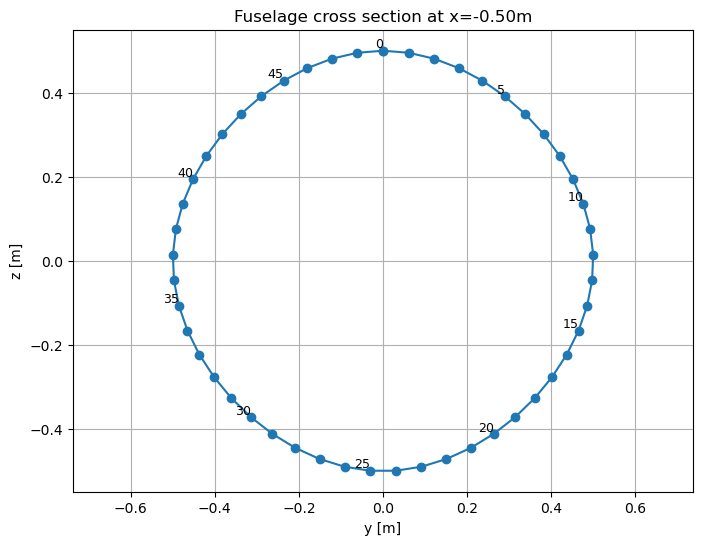

In [11]:
plt.figure(figsize=(8, 6))
plt.plot(y_coords, z_coords, marker='o', linestyle='-')

for i in range(0, len(y_coords), 5):
    plt.text(
        y_coords[i], z_coords[i],
        str(i),
        fontsize=9,
        ha='right', va='bottom'
    )

plt.title('Fuselage cross section at x=%.2fm'%x_coord)
plt.xlabel('y [m]')
plt.ylabel('z [m]')
plt.grid(True)
plt.axis('equal')
plt.show()

5. Get loft

In [12]:
fuselage_loft = fuselage.get_loft()

In [13]:
renderer = JupyterRenderer(size=(700,700))
renderer.DisplayShape(fuselage_loft.shape(), transparency=True)
renderer.Display()

In [14]:
help(fuselage)

Help on CCPACSFuselage in module tigl3.configuration object:

class CCPACSFuselage(CPACSFuselage, CTiglRelativelyPositionedComponent)
 |  CCPACSFuselage(parent: 'CCPACSFuselages', uidMgr: 'CTiglUIDManager')
 |  
 |  C++ includes: CCPACSFuselage.h
 |  
 |  Method resolution order:
 |      CCPACSFuselage
 |      CPACSFuselage
 |      tigl3.core.CTiglReqUIDObject
 |      tigl3.core.CTiglUIDObject
 |      tigl3.core.ITiglUIDRefObject
 |      CTiglRelativelyPositionedComponent
 |      tigl3.geometry.CTiglAbstractGeometricComponent
 |      tigl3.geometry.ITiglGeometricComponent
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, parent: 'CCPACSFuselages', uidMgr: 'CTiglUIDManager')
 |      __init__(CCPACSFuselage self, CCPACSFuselages parent, CTiglUIDManager uidMgr) -> CCPACSFuselage
 |      
 |      Parameters
 |      ----------
 |      parent: tigl::CCPACSFuselages *
 |      uidMgr: tigl::CTiglUIDManager *
 |  
 |  __repr__ = _swig_repr(self)
 |  
 |  get_circumf